In [38]:
import sys
import os
import regex as re
import json

gt_json = '/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco.json'
gt_dir = gt_json.split('.json')[0]
eval_sessions_og = '''
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed
'''.strip().split('\n')

eval_sessions_mc = '''
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T19:50-MaskCLIP-completed
'''.strip().split('\n')

eval_sessions = eval_sessions_og

eval_runs = []
n_sessions = len(eval_sessions)
n_runs = 0
for session in eval_sessions:
    
    runs = os.listdir(session)
    for run in runs:
        # parse metrics/2025-02-15T19:58-completed/agents-12_remove_dyn_objs-True

        match = re.match(r'agents-(\d+)_remove_dyn_objs-(True|False)', run)
        if match is None:
            continue
        agents, rdo = match.groups()
        n_runs += 1

        run_json_file = f'{session}/{run}/semseg_preds.json'
        if not os.path.exists(run_json_file):
            assert rdo == 'True' or '1' not in agents, f"{run_json_file} does not exist but should"
            continue
        
        with open(run_json_file, 'r') as f:
            run_json = json.load(f)
            n_preds = len(run_json['annotations'])
            assert n_preds == 100, f"Expected 100 predictions, got {n_preds}!"
                

        run_dir = f'{session}/{run}/semseg_preds'
        

        run_data = {'session': session, 'run': run, 'agents': agents, 'n_agents': len(agents), 'run_json': run_json_file, 'run_dir': run_dir}
        eval_runs.append(run_data)

print("gt json:", gt_json)
print("gt dir:", gt_dir)
print(f'Found {len(eval_runs)} landmark results files in {n_runs} runs over {n_sessions} sessions')
eval_runs


gt json: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco.json
gt dir: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco
Found 4 landmark results files in 4 runs over 1 sessions


[{'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed',
  'run': 'agents-1_remove_dyn_objs-False',
  'agents': '1',
  'n_agents': 1,
  'run_json': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-1_remove_dyn_objs-False/semseg_preds.json',
  'run_dir': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-1_remove_dyn_objs-False/semseg_preds'},
 {'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed',
  'run': 'agents-012_remove_dyn_objs-False',
  'agents': '012',
  'n_agents': 3,
  'run_json': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-012_remove_dyn_objs-False/semseg_preds.json',
  'run_dir': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-012_remove_dyn_objs-False/semseg_preds'},
 {'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed

# evaluating for (1,2,3) agents
results_all are the results if a landmark has to be observed by all agents
results_any are the results if a lanmark can be observed by any of the agents

In [39]:
import sys
sys.path.append('/workspaces/collaborative-scene-graphs/src/curb_metrics/scripts/')
import panoptic_metrics
import os
import contextlib

from tqdm import tqdm

results = []

for run in tqdm(eval_runs):
    with open(os.devnull, "w") as f, contextlib.redirect_stdout(f):
        results = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, run['run_json'], run['run_dir'], resultsFile=None, min_obs_agents=1, max_occl=0.5)
        run['results_any'] = results['All']
        if run['n_agents'] > 1:
            result_all = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, run['run_json'], run['run_dir'], resultsFile=None, min_obs_agents=run['n_agents'], max_occl=0.5)
            run['results_all'] = result_all['All']
eval_runs[0]

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:13<00:00,  3.31s/it]


{'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed',
 'run': 'agents-1_remove_dyn_objs-False',
 'agents': '1',
 'n_agents': 1,
 'run_json': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-1_remove_dyn_objs-False/semseg_preds.json',
 'run_dir': '/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed/agents-1_remove_dyn_objs-False/semseg_preds',
 'results_any': {'miou': 0.30678178186062616,
  'p': 0.8623271889400921,
  'r': 0.182685649991345,
  'pq': 0.08816169848496402,
  'sq': 0.30678178186062616,
  'rq': 0.29583333333333334,
  'n': 2}}

In [40]:
from collections import defaultdict
import numpy as np

aggregated_runs = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for run in eval_runs:
    n_agents = run['n_agents']
    for results_type in ['results_all', 'results_any']:
        if n_agents == 1 and results_type == 'results_all':
            continue
        for metric in ['miou', 'p', 'r']:
            aggregated_runs[n_agents][results_type][metric] += [run[results_type][metric]]

metrics_by_na_by_rt = defaultdict(lambda: defaultdict(dict))
for n_agents, agg_metrics_by_rt in aggregated_runs.items():
    for results_type, metrics in agg_metrics_by_rt.items():
        for metric, values in metrics.items():
            metrics_by_na_by_rt[n_agents][results_type][metric] = float(np.mean(values))

In [14]:
print("{:^7s}  {:^13s}  {:^6s}  {:^6s}  {:^6s} ".format('N agents', 'observed by', 'MIOU', 'P', 'R'))
print("-" * 47)
for n_agents, metrics_by_rt in sorted(metrics_by_na_by_rt.items()):
    for rt, metrics in reversed(sorted(metrics_by_rt.items())):
        if n_agents == 1 and rt == 'results_all':
            continue
        observed_by_str = 'any agent' if rt == 'results_any' else 'all agents'
        print("{:^8d}  {:^13s}  {:^ .4f}  {:^ .4f}  {:^ .4f} ".format(n_agents, rt, metrics['miou'], metrics['p'], metrics['r']))
    print()
# for run in averaged_runs:
#     print("{:^8d}  {:^13s}  {:^ 2.3f}  {:^ 2.3f}  {:^ 2.3f} ".format(run['n_agents'], 'any agent', run['results_any']['miou']*100, run['results_any']['p']*100, run['results_any']['r']*100))
#     print("{:^8d}  {:^13s}  {:^ 2.3f}  {:^ 2.3f}  {:^ 2.3f} ".format(run['n_agents'], 'all agents', run['results_all']['miou']*100, run['results_all']['p']*100, run['results_all']['r']*100))
#     print()

N agents   observed by    MIOU     P       R    
-----------------------------------------------
   1       results_any    0.3068   0.8623   0.1827 

   2       results_any    0.2888   0.8211   0.2525 
   2       results_all    0.2931   0.9167   0.1475 

   3       results_any    0.3127   0.7122   0.2418 
   3       results_all    0.3815   1.0000   0.1006 



OG:
```
N agents   observed by    MIOU     P       R    
-----------------------------------------------
   1       results_any    30.678   86.233   18.269 

   2       results_any    28.881   82.106   25.247 
   2       results_all    29.312   91.667   14.754 

   3       results_any    31.274   71.217   24.182 
   3       results_all    38.147   100.000   10.062 

```

# evaluating for mc/og comparison

In [31]:
from copy import deepcopy
metrics_by_rt = defaultdict(lambda: defaultdict(float))
n = 0
for run in eval_runs:
    n += 1
    for results_type in ['results_all', 'results_any']:
        if run['n_agents'] == 1 and results_type == 'results_all':
            continue
        for metric in ['miou', 'p', 'r']:
            metrics_by_rt[results_type][metric] += run[results_type][metric]

for rt, metrics in metrics_by_rt.items():
    for metric in metrics:
        metrics[metric] /= n


for rt, metrics in metrics_by_rt.items():
    anyall = 'any' if 'any' in rt else 'all'
    print(f"mmiou_{anyall}, mp_{anyall}, mr_{anyall} = {metrics['miou']}, {metrics['p']}, {metrics['r']}")

mmiou_any, mp_any, mr_any = 0.29508312111743484, 0.690064383038076, 0.23647455963603906
mmiou_all, mp_all, mr_all = 0.2701327847311234, 0.6828921261487051, 0.08535752071944983


In [1]:

print("{:^7s}|  {:^6s}  {:^6s}  {:^6s} ".format('Method', 'MIOU', 'P', 'R'))
print("-" * 47)
# MASKCLIP ################
mmiou_any, mp_any, mr_any = 0.29508312111743484, 0.690064383038076, 0.23647455963603906
mmiou_all, mp_all, mr_all = 0.2701327847311234, 0.6828921261487051, 0.08535752071944983
print("MaskCLIP@all|  {:^ .4f}  {:^ .4f}  {:^ .4f} ".format(mmiou_all, mp_all, mr_all))
# print("MaskCLIP@any|  {:^ .3f}  {:^ .3f}  {:^ .3f} ".format(mmiou_any, mp_any, mr_any))

# OPENGRAPH ################
# mmiou, mp, mr = 0.2559569278172166, 0.6131558334854096, 0.12839754552204868
mmiou_all, mp_all, mr_all = 0.31829295018379833, 0.8821978494703545, 0.14924641560003915
mmiou_any, mp_any, mr_any = 0.29880906264799123, 0.7094406377117364, 0.24377186347963703
print("OpenGraph@all|  {:^ .4f}  {:^ .4f}  {:^ .4f} ".format(mmiou_all, mp_all, mr_all))
# print("OpenGraph@any|  {:^ .3f}  {:^ .3f}  {:^ .3f} ".format(mmiou_any, mp_any, mr_any))


Method |   MIOU     P       R    
-----------------------------------------------
MaskCLIP@all|   0.2701   0.6829   0.0854 
OpenGraph@all|   0.3183   0.8822   0.1492 


# plotting precision/recall curves

In [42]:
eval_runs

[{'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-15T19:58-completed',
  'run': 'agents-1_remove_dyn_objs-False',
  'agents': '1',
  'n_agents': 1,
  'run_json': '/workspaces/collaborative-scene-graphs/metrics/2025-02-15T19:58-completed/agents-1_remove_dyn_objs-False/semseg_preds.json',
  'run_dir': '/workspaces/collaborative-scene-graphs/metrics/2025-02-15T19:58-completed/agents-1_remove_dyn_objs-False/semseg_preds',
  'results_all': {'miou': 0.33356327783649997,
   'p': 0.8357142857142856,
   'r': 0.22098330725091286,
   'pq': 0.11430774573498166,
   'sq': 0.33356327783649997,
   'rq': 0.3461949814890991,
   'n': 2},
  'results_any': {'miou': 0.3454630473065228,
   'p': 0.8362607828408102,
   'r': 0.2328890559693251,
   'pq': 0.11430774573498166,
   'sq': 0.33356327783649997,
   'rq': 0.3461949814890991,
   'n': 2},
  'n': 3},
 {'session': '/workspaces/collaborative-scene-graphs/metrics/2025-02-15T19:58-completed',
  'run': 'agents-012_remove_dyn_objs-False',
  'ag

In [5]:
import sys
sys.path.append('/workspaces/collaborative-scene-graphs/src/curb_metrics/scripts/')
import panoptic_metrics
import os
import contextlib

from tqdm import tqdm
import numpy as np

max_occls = np.linspace(0.1, 0.95, 10)

for run in tqdm(eval_runs):
    if run['n_agents'] < 2:
        continue
    run['results_occltrial'] = []
    for max_occl in max_occls:
        with open(os.devnull, "w") as f, contextlib.redirect_stdout(f):
            results = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, run['run_json'], run['run_dir'], resultsFile=None, max_occl=max_occl)
        run['results_occltrial'].append(results['All'])

# results_per_occl = []
# run_json_file = "/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35/agents-1_remove_dyn_objs-False/semseg_preds.json"
# run_dir = "/workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35/agents-1_remove_dyn_objs-False/semseg_preds"
# for max_occl in max_occls:
#     with open(os.devnull, "w") as f, contextlib.redirect_stdout(f):
#         results = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, run_json_file, run_dir, resultsFile=None, max_occl=max_occl)
#     results_per_occl.append(results['All'])


100%|██████████| 4/4 [01:14<00:00, 18.74s/it]


Best occlusion threshold: 0.95


/tmp/ipykernel_3325664/2969155139.py:37: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(colorizer, label='occlusion threshold', )


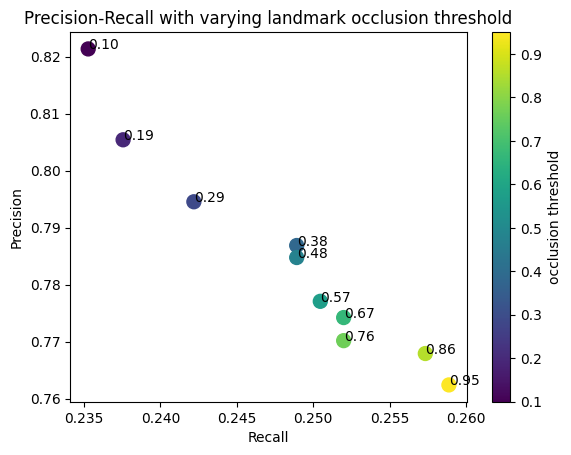

In [9]:
from unittest import result


p = []
r = []

for run in eval_runs:
    if run['n_agents'] < 2:
        continue
    p.append([result['p'] for result in run['results_occltrial']])
    r.append([result['r'] for result in run['results_occltrial']])

# p.append([[result['p'] for result in results_per_occl]])
# r.append([[result['r'] for result in results_per_occl]])
p = np.array(p)
r = np.array(r)

p = p.mean(axis=0)
r = r.mean(axis=0)

f1 = 2 * p * r / (p + r)
best_occl = max_occls[np.argmax(f1)]
print(f"Best occlusion threshold: {best_occl}")

import matplotlib.pyplot as plt
from numpy import size
# plot precision/recall with varying max occlusion threshold indicated by color map
plt.figure()
# for i,occl in enumerate(max_occls):
#     plt.scatter(r[i], p[i], c=occl*1000, cmap='viridis')
plt.scatter(r, p, c=max_occls, cmap='viridis', s=100)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall with varying landmark occlusion threshold')
colorizer  = plt.cm.ScalarMappable(cmap='viridis')
colorizer.set_array(max_occls)
plt.colorbar(colorizer, label='occlusion threshold', )
# put labels on the scatter points
for i, occl in enumerate(max_occls):
    plt.text(r[i], p[i], f"{occl:.2f}")
    


plt.show()
